# Compare market production methods (savegame)

Loads **format-2** `.pkl` snapshots from `analysis/savegame/notebooks/save_game_temp` (same pipeline as `compare_savegames_market.ipynb`): `locations` (already merged with region hierarchy), `buildings` (production methods per building), `market_goods`, etc.

**Recipe weights and PM slot groups** (food / drinks / packaging) are loaded from **`game_path` / `mod_path`** in your config via `BuildingData`—the same definitions as `production_method_comparison.ipynb`. Snapshots only store *which* PM each building uses; they do not embed recipe quantities.

Filters to one building type (default **`cookery`**, e.g. Prosper or Perish). Use `first_savegame` / `last_savegame` to slice snapshots (`last_savegame = 1` with `first_savegame = 0` for a single file).

**Global resource usage:** for the **latest** snapshot, three tables (**food** / **drinks** / **packaging**) list each trade **good** and **total_input** = sum over all cookery buildings of (recipe input parsed from `building_types` × buildings using that PM). PMs with no goods (e.g. well water, no packaging) contribute no rows. Locations are merged with **`LocationData`** (`merge_saves_with_location_data`) so **`macro_region`** is available; one column per macro region (slug as column name, same units as `total_input`), ordered by **descending column total** within that category so the largest regional footprints appear first. Missing macro region is bucketed as **`__unknown`**. Each table also includes **base_cost** (game `default_market_price` from merged goods definitions) and **total_cost** = `total_input` × `base_cost`.

**Global PM table:** counts how many cookery buildings use each `pp_cookery_*` method in the **latest** loaded snapshot (so totals are not multiplied when you load many time slices). Rows are grouped into **food**, **drinks**, and **packaging** to match the three `unique_production_methods` slots in the Prosper or Perish cookery building.

**Regional PM preferences:** three wide tables (`regional_prefs_food` / `regional_prefs_drinks` / `regional_prefs_packaging`) give, for each **macro region**, the **percentage share** of each production method in that slot as **whole-number** percentages (rows sum to ~100% per region); column names drop the `pp_cookery_` prefix for readability. PM columns are ordered by global usage in that slot (most common first).

**Regional spend mix:** three wide tables (`regional_spend_share_food` / `regional_spend_share_drinks` / `regional_spend_share_packaging`) show, for each **macro region**, the **percentage** of **base-price** cookery input spend (recipe quantity × `default_market_price` per trade good) allocated to each **good** in that slot; rows match regional PM ordering, good columns by descending global spend in that slot.

**Time-series plots:** when you load **multiple** snapshots, three line charts show how many buildings globally use each production method in the food, drink, and packaging slots over time (one line per `pp_cookery_*` method in that slot). The horizontal axis matches **`compare_savegames.ipynb`**: snapshot index 0, 1, … is labeled as **game years** (`start_year` 1337 + index × `years_per_snapshot` 5).

Pkls must include a **`buildings`** key (re-run the savegame watcher / processor with current ProsperPerishCalcs if yours were produced before that field existed).

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from IPython.display import display

from core.parser.path_resolver import PathResolver
from core.data.building_data import BuildingData
from core.data.goods_data import GoodsData
from analysis.building_levels.building_analysis import load_config
from analysis.savegame import (
    buildings_df_from_pkl,
    locations_df_from_pkl,
    resolve_pkl_dir,
)
from analysis.savegame.datalocations import merge_saves_with_location_data

pd.options.display.max_columns = None
pd.options.display.width = 200

In [56]:
# Cookery: three UPM slots from parsed mod `building_types` (same source as production_method_comparison)
config = load_config()
path_resolver = PathResolver(config["game_path"], config["mod_path"])
building_data = BuildingData(path_resolver)
building_data.load_all()

goods_data = GoodsData(path_resolver)
goods_data.load_all()

cookery_maps = building_data.cookery_pm_maps("cookery")

_COOKERY_PM_FOOD = cookery_maps.food
_COOKERY_PM_DRINKS = cookery_maps.drinks
_COOKERY_PM_PACKAGING = cookery_maps.packaging
_COOKERY_PM_GOOD_INPUTS = cookery_maps.pm_good_inputs


def _cookery_pm_category(pm: str) -> str:
    return cookery_maps.category(pm)


In [57]:
"""Load .pkl snapshots (format-2 with market_goods + buildings)."""

# None = auto (newest playthrough under save_game_temp), or set path to your playthrough folder
PKL_PATH = None  # e.g. ".../save_game_temp/<playthrough_id>"
first_savegame = 0
last_savegame = None  # None = all; use 1 with first_savegame=0 for one snapshot only

pkl_dir = resolve_pkl_dir(PKL_PATH)
pkl_files = sorted(pkl_dir.glob("*.pkl"), key=lambda p: p.stem)
if last_savegame is not None:
    pkl_files = pkl_files[first_savegame:last_savegame]
else:
    pkl_files = pkl_files[first_savegame:]

raw = {p.stem: pd.read_pickle(p) for p in pkl_files}

for label, payload in raw.items():
    if not isinstance(payload, dict) or "market_goods" not in payload:
        raise TypeError(
            f"{label}: expected format-2 pkl with 'market_goods'. Got {type(payload).__name__}"
        )
    if "buildings" not in payload:
        raise ValueError(
            f"{label}: pkl has no 'buildings' key. Regenerate snapshots with the current "
            "savegame processor / watcher (format-2 now includes buildings)."
        )

_locations_merged = merge_saves_with_location_data(raw)

n_snap = len(raw)
print(f"Loaded {n_snap} snapshot(s) from {pkl_dir}")
print(f"Labels: {list(raw.keys())}")

Loaded 56 snapshot(s) from C:\Development\ProsperPerishCalcs\analysis\savegame\notebooks\save_game_temp\5f0b39de_c5da_4afa_ba3e_c6fc282a7fc5
Labels: ['20260322_202007', '20260322_202130', '20260322_202250', '20260322_202408', '20260322_202528', '20260322_202653', '20260322_202815', '20260322_202937', '20260322_203103', '20260322_203225', '20260322_203345', '20260322_203509', '20260322_203635', '20260322_203759', '20260322_203929', '20260322_204056', '20260322_204218', '20260322_204344', '20260322_204509', '20260322_204632', '20260322_204754', '20260322_204912', '20260322_205028', '20260322_205146', '20260322_205302', '20260322_205419', '20260322_205535', '20260322_205654', '20260322_205813', '20260322_205931', '20260322_210048', '20260322_210205', '20260322_210328', '20260322_210459', '20260322_210621', '20260322_210738', '20260322_210857', '20260322_211017', '20260322_211141', '20260322_211307', '20260322_211434', '20260322_211601', '20260322_211726', '20260322_211846', '20260322_2120

In [58]:
# Building type to analyze (Prosper or Perish cookery); set to None to include all building types
BUILDING_SLUG = "cookery"

parts = []
for label, payload in raw.items():
    b = buildings_df_from_pkl(payload)
    if BUILDING_SLUG and "slug" in b.columns:
        b = b[b["slug"] == BUILDING_SLUG].copy()
    b["snapshot"] = label
    loc = _locations_merged.get(label)
    if not isinstance(loc, pd.DataFrame) or "location_id" not in loc.columns:
        loc = locations_df_from_pkl(payload)
    if "macro_region" not in loc.columns:
        for alias in ("macro_region_loc", "macro_region_pkl"):
            if alias in loc.columns:
                loc = loc.copy()
                loc["macro_region"] = loc[alias]
                break
    scope = [c for c in ("region", "macro_region", "super_region") if c in loc.columns]
    if "location_id" not in loc.columns or not scope:
        raise ValueError(f"{label}: locations frame missing location_id or scope columns.")
    # Omit location `slug` so it does not collide with building `slug`
    loc_sub = loc[["location_id", *scope]].drop_duplicates(subset=["location_id"])
    merged = b.merge(loc_sub, on="location_id", how="left", suffixes=("", "_loc"))
    parts.append(merged)

enriched = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
# if not enriched.empty:
#     display(enriched.head(20))
# else:
#     slug_msg = f"slug={BUILDING_SLUG!r}" if BUILDING_SLUG else "all slugs"
#     print(f"No matching buildings ({slug_msg}) in selected snapshot(s).")

In [59]:
# Global PM table (latest snapshot only)
if enriched.empty:
    pm_global = pd.DataFrame()
    print("No data for global PM counts.")
else:
    # Latest snapshot only: one world state, not N × duplicate buildings across time slices
    if "snapshot" in enriched.columns:
        _last_snap = sorted(enriched["snapshot"].astype(str).unique())[-1]
        _base = enriched[enriched["snapshot"] == _last_snap]
        print(f"Global PM counts use snapshot: {_last_snap}")
    else:
        _base = enriched

    pm_long = _base.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    pm_long = pm_long[pm_long["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    counts = pm_long["production_method"].value_counts()
    pm_global = counts.rename("building_uses").reset_index()
    pm_global.columns = ["production_method", "building_uses"]
    pm_global["category"] = pm_global["production_method"].map(_cookery_pm_category)
    _cat_order = {"food": 0, "drinks": 1, "packaging": 2, "other": 3}
    pm_global["_k"] = pm_global["category"].map(_cat_order)
    pm_global = (
        pm_global.sort_values(["_k", "building_uses", "production_method"], ascending=[True, False, True])
        .drop(columns=["_k"])
        .reset_index(drop=True)
    )
    display(pm_global)
    cat_totals = (
        pm_global.groupby("category", sort=False)["building_uses"]
        .sum()
        .reindex(["food", "drinks", "packaging", "other"], fill_value=0)
        .rename("sum_building_uses")
        .to_frame()
    )
    display(cat_totals)

Global PM counts use snapshot: 20260322_213520


,production_method,building_uses,category
0,pp_cookery_livestock_pottage,383,food
1,pp_cookery_mutton_and_pease,297,food
2,pp_cookery_pemmican,259,food
3,pp_cookery_fish_congee,197,food
4,pp_cookery_meat_tajine,181,food
5,pp_cookery_khichdi,176,food
6,pp_cookery_ika_mata,170,food
7,pp_cookery_mediterranean_fish,152,food
8,pp_cookery_saltfish_porridge,90,food
9,pp_cookery_kheer,75,food


,sum_building_uses
category,
food,2187
drinks,2187
packaging,2187
other,0


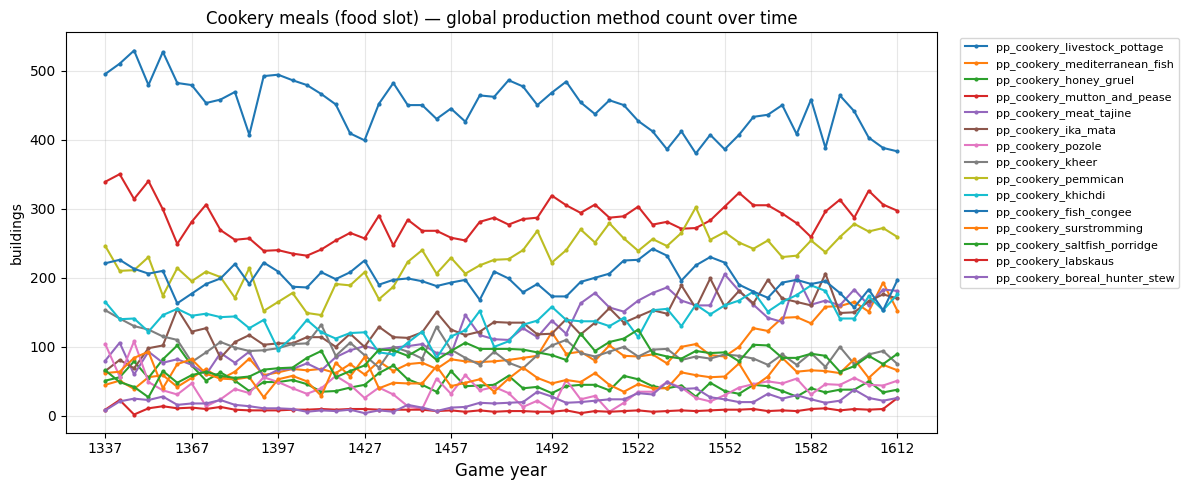

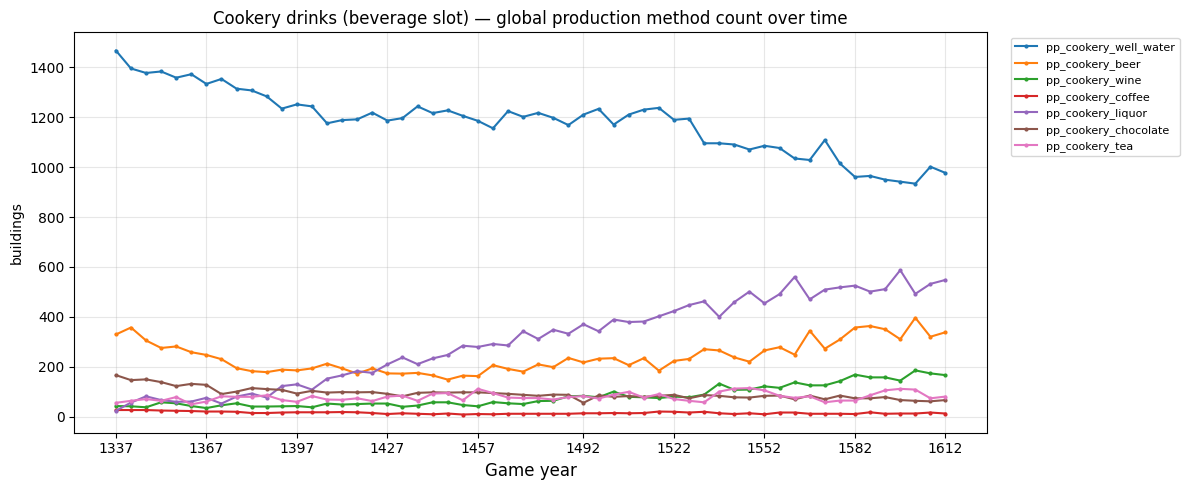

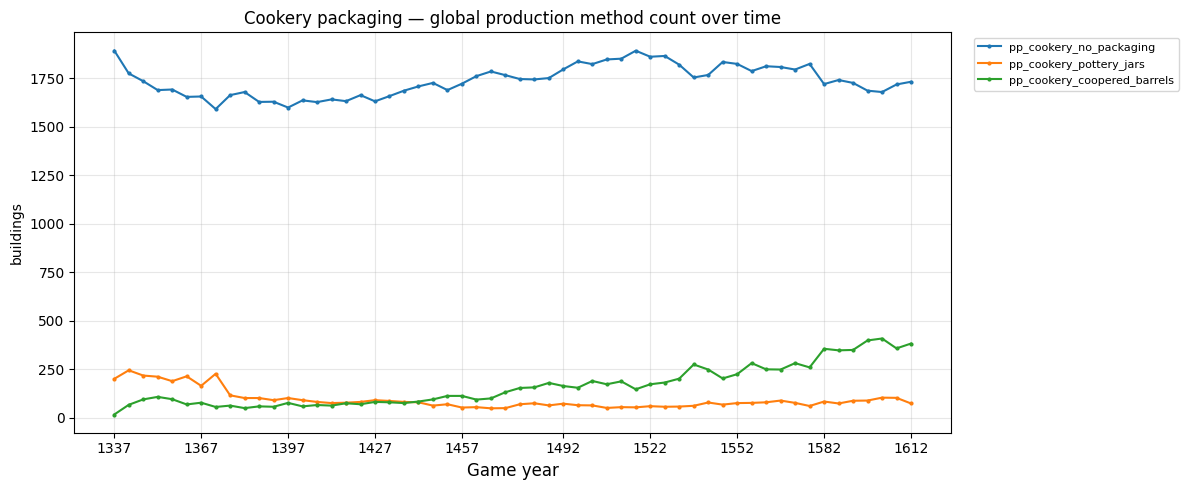

In [60]:
# Time series: global cookery PM counts per snapshot (meals / drinks / packaging slots)
if enriched.empty or "snapshot" not in enriched.columns:
    print("No time-series data (need non-empty enriched with snapshot).")
else:
    pm_ts = enriched.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    pm_ts = pm_ts[pm_ts["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    pm_ts["category"] = pm_ts["production_method"].map(_cookery_pm_category)
    pm_ts = pm_ts[pm_ts["category"] != "other"]
    if pm_ts.empty:
        print("No pp_cookery_* production methods to plot.")
    else:
        counts = (
            pm_ts.groupby(["snapshot", "category", "production_method"], sort=False)
            .size()
            .rename("n")
        )
        snap_order = sorted(enriched["snapshot"].astype(str).unique())
        # X-axis: same convention as compare_savegames.ipynb (snapshot index -> game year)
        years_per_snapshot = 5
        start_year = 1337  # EU5 start
        n_ticks = 10
        n = len(snap_order)
        x_pos = list(range(n))
        if n <= 1:
            tick_positions = list(range(n))
        elif n <= n_ticks:
            tick_positions = list(range(n))
        else:
            step = (n - 1) / (n_ticks - 1)
            tick_positions = [int(round(i * step)) for i in range(n_ticks)]
        tick_labels = [start_year + pos * years_per_snapshot for pos in tick_positions]

        _slot_titles = {
            "food": "Cookery meals (food slot) — global production method count over time",
            "drinks": "Cookery drinks (beverage slot) — global production method count over time",
            "packaging": "Cookery packaging — global production method count over time",
        }
        for cat in ("food", "drinks", "packaging"):
            try:
                sub = counts.xs(cat, level="category")
            except KeyError:
                print(f"Skip time-series plot: no rows for category {cat!r}.")
                continue
            wide = sub.unstack(level="production_method", fill_value=0)
            wide = wide.reindex(snap_order).fillna(0).astype(int)
            if wide.empty:
                print(f"Skip time-series plot: empty pivot for {cat!r}.")
                continue
            fig, ax = plt.subplots(figsize=(12, 5))
            for col in wide.columns:
                ax.plot(x_pos, wide[col].values, label=col, marker="o", markersize=2)
            ax.set_title(_slot_titles[cat])
            ax.set_ylabel("buildings")
            ax.set_xlabel("Game year", fontsize=12)
            ax.tick_params(axis="both", labelsize=10)
            ax.grid(True, axis="both", alpha=0.3, linestyle="-")
            ax.set_xticks(tick_positions)
            ax.set_xticklabels(tick_labels)
            ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
            fig.tight_layout()
            plt.show()

In [61]:
# Global trade-good input usage (latest snapshot), by slot category — recipe inputs from
# Parsed per-PM trade-good inputs (_COOKERY_PM_GOOD_INPUTS) × count of cookery buildings using each PM.
if enriched.empty:
    print("No data for global resource usage.")
else:
    if "snapshot" in enriched.columns:
        _last_snap = sorted(enriched["snapshot"].astype(str).unique())[-1]
        _base = enriched[enriched["snapshot"] == _last_snap]
        print(f"Global resource usage — snapshot {_last_snap}")
    else:
        _base = enriched
    ex = _base.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    ex = ex[ex["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    if ex.empty:
        print("No pp_cookery_* production methods in this slice.")
    else:
        def _mr_col_suffix(mr):
            if pd.isna(mr):
                return "__unknown"
            return str(mr).strip().replace(" ", "_")

        pm_counts = ex["production_method"].value_counts()
        if "macro_region" in ex.columns:
            _mr_levels = sorted(
                {_mr_col_suffix(mr) for mr, _ in ex.groupby("macro_region", dropna=False)}
            )
        else:
            _mr_levels = []
            print(
                "No macro_region on building rows; omitting per-macro_region columns "
                "(use merged locations / pkls with hierarchy)."
            )
        for cat in ("food", "drinks", "packaging"):
            totals = defaultdict(float)
            for pm, n in pm_counts.items():
                if _cookery_pm_category(pm) != cat:
                    continue
                for good, qty in _COOKERY_PM_GOOD_INPUTS.get(pm, {}).items():
                    totals[good] += float(n) * float(qty)
            if not totals:
                print(f"\n{cat}: no trade-good inputs (empty recipe or no buildings).")
                continue
            totals_reg = defaultdict(lambda: defaultdict(float))
            if _mr_levels:
                for mr, ex_mr in ex.groupby("macro_region", dropna=False):
                    mk = _mr_col_suffix(mr)
                    pm_counts_mr = ex_mr["production_method"].value_counts()
                    for pm, n in pm_counts_mr.items():
                        if _cookery_pm_category(pm) != cat:
                            continue
                        for good, qty in _COOKERY_PM_GOOD_INPUTS.get(pm, {}).items():
                            totals_reg[good][mk] += float(n) * float(qty)
            df = pd.DataFrame(
                sorted(totals.items(), key=lambda kv: -kv[1]),
                columns=["good", "total_input"],
            )
            df["total_input"] = df["total_input"].round(2)
            df.insert(0, "category", cat)
            if _mr_levels:
                mr_cols = list(_mr_levels)
                for mrk in mr_cols:
                    df[mrk] = [
                        round(totals_reg[g].get(mrk, 0.0), 2) for g in df["good"]
                    ]
                _mr_order = df[mr_cols].sum().sort_values(ascending=False).index.tolist()
                df = df[["category", "good", "total_input", *_mr_order]]
            df["base_cost"] = df["good"].map(goods_data.modded_df["default_market_price"])
            df["total_cost"] = (df["total_input"] * df["base_cost"]).round(2)
            if _mr_levels:
                df = df[["category", "good", "total_input", "total_cost", "base_cost", *_mr_order]]
            else:
                df = df[["category", "good", "total_input", "total_cost", "base_cost"]]
            _missing = df.loc[df["base_cost"].isna(), "good"].tolist()
            if _missing:
                print(f"  Warning: no default_market_price in merged goods for: {_missing}")
            print(f"\n--- {cat} ---")
            display(df)

Global resource usage — snapshot 20260322_213520

--- food ---


,category,good,total_input,total_cost,base_cost,western_europe,east_asia,eastern_europe,south_east_asia,south_asia,middle_east,north_america,east_africa,west_africa,north_africa,central_asia,south_america,southern_africa,central_africa,north_asia,pacific_islands
0,food,fish,2678.05,2678.05,1.00,833.06,345.12,297.99,517.94,168.33,110.36,88.00,100.03,62.28,134.52,0.00,12.00,3.74,0.00,0.00,4.68
1,food,livestock,1970.60,2955.90,1.50,636.35,365.76,273.33,23.70,154.14,143.08,11.28,88.72,112.56,44.20,83.56,26.74,5.30,0.94,0.94,0.00
2,food,rice,1478.40,1478.40,1.00,151.80,650.10,16.50,316.80,201.30,62.70,0.00,26.40,39.60,6.60,3.30,0.00,3.30,0.00,0.00,0.00
3,food,wheat,1316.80,1316.80,1.00,462.40,227.20,269.60,0.00,70.40,92.00,0.00,53.60,32.00,29.60,80.00,0.00,0.00,0.00,0.00,0.00
4,food,wild_game,1298.10,1298.10,1.00,382.50,310.50,153.00,45.00,94.50,31.50,178.80,13.50,18.00,0.00,40.50,21.30,0.00,4.50,4.50,0.00
5,food,legumes,1242.47,1242.47,1.00,381.65,351.80,139.01,59.56,83.58,115.49,28.56,14.89,19.39,19.67,28.87,0.00,0.00,0.00,0.00,0.00
6,food,wool,1054.35,1317.94,1.25,472.15,46.15,163.30,7.10,85.20,138.45,60.35,3.55,21.30,31.95,24.85,0.00,0.00,0.00,0.00,0.00
7,food,fruit,1034.02,1034.02,1.00,287.32,173.80,70.47,141.60,79.96,69.45,67.00,42.89,47.40,20.97,26.56,3.00,1.60,1.00,1.00,0.00
8,food,millet,317.02,317.02,1.00,90.47,40.36,77.55,20.27,23.15,2.60,0.00,34.74,18.20,6.61,0.00,0.00,2.60,0.00,0.00,0.47
9,food,olives,228.00,228.00,1.00,127.50,0.00,49.50,0.00,0.00,19.50,0.00,0.00,0.00,31.50,0.00,0.00,0.00,0.00,0.00,0.00



--- drinks ---


,category,good,total_input,total_cost,base_cost,western_europe,east_asia,eastern_europe,south_asia,middle_east,south_east_asia,north_america,north_africa,west_africa,central_asia,east_africa,south_america,pacific_islands,central_africa,southern_africa,north_asia
0,drinks,liquor,904.2,2260.5,2.5,374.55,161.70,79.20,72.6,49.50,69.30,0.00,39.60,16.50,26.4,11.55,0.0,0.0,1.65,1.65,0.0
1,drinks,beer,659.1,1318.2,2.0,319.80,87.75,56.55,58.5,48.75,46.80,5.85,5.85,17.55,3.9,3.90,3.9,0.0,0.00,0.00,0.0
2,drinks,wine,348.6,697.2,2.0,147.00,77.70,50.40,14.7,33.60,8.40,2.10,6.30,2.10,4.2,0.00,0.0,2.1,0.00,0.00,0.0
3,drinks,tea,108.0,324.0,3.0,0.00,98.55,0.00,2.7,0.00,6.75,0.00,0.00,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.0
4,drinks,cocoa,52.8,211.2,4.0,0.00,0.00,0.00,0.0,0.00,0.00,52.80,0.00,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.0
5,drinks,coffee,12.6,37.8,3.0,0.00,0.00,0.00,0.0,1.05,0.00,0.00,1.05,0.00,0.0,10.50,0.0,0.0,0.00,0.00,0.0



--- packaging ---


,category,good,total_input,total_cost,base_cost,western_europe,east_asia,south_east_asia,eastern_europe,south_asia,middle_east,west_africa,north_america,central_asia,north_africa,pacific_islands,east_africa,central_africa,north_asia,south_america,southern_africa
0,packaging,furniture,343.8,1031.4,3.0,127.8,75.6,58.5,22.5,27.9,14.4,4.5,0.9,4.5,5.4,0.9,0.9,0.0,0.0,0.0,0.0
1,packaging,pottery,204.4,204.4,1.0,42.0,56.0,11.2,42.0,11.2,22.4,8.4,8.4,2.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [62]:
# Regional PM preferences (latest snapshot): per macro-region % share of each slot's PM assignments.
import numpy as np


def _mr_col_suffix_prefs(mr):
    if pd.isna(mr):
        return "__unknown"
    return str(mr).strip().replace(" ", "_")


regional_prefs_food = pd.DataFrame()
regional_prefs_drinks = pd.DataFrame()
regional_prefs_packaging = pd.DataFrame()

if enriched.empty:
    print("No data for regional PM preferences.")
else:
    if "snapshot" in enriched.columns:
        _last_snap = sorted(enriched["snapshot"].astype(str).unique())[-1]
        _base_pref = enriched[enriched["snapshot"] == _last_snap]
    else:
        _base_pref = enriched
    ex_pref = _base_pref.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    ex_pref = ex_pref[ex_pref["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    if "macro_region" not in ex_pref.columns:
        print("No macro_region; skipping regional PM preference tables.")
    elif ex_pref.empty:
        print("No pp_cookery_* rows for regional PM preferences.")
    else:
        ex_pref = ex_pref.copy()
        ex_pref["_mr"] = ex_pref["macro_region"].map(_mr_col_suffix_prefs)

        _mr_cookery_order = (
            _base_pref.assign(_mr=_base_pref["macro_region"].map(_mr_col_suffix_prefs))
            .groupby("_mr", observed=False)
            .size()
            .sort_values(ascending=False)
            .index.tolist()
        )

        def _regional_pm_pct(cat: str, mr_order: list) -> pd.DataFrame:
            sub = ex_pref[ex_pref["production_method"].map(_cookery_pm_category) == cat]
            if sub.empty:
                return pd.DataFrame()
            ct = sub.groupby(["_mr", "production_method"], observed=False).size().unstack(fill_value=0)
            denom = ct.sum(axis=1).replace(0, np.nan)
            pct = (ct.div(denom, axis=0) * 100).fillna(0)
            col_order = ct.sum(axis=0).sort_values(ascending=False).index.tolist()
            pct = pct.reindex(columns=col_order)
            pct.columns = [str(c).removeprefix("pp_cookery_") for c in pct.columns]
            pct = np.rint(pct).astype(int)
            idx = [i for i in mr_order if i in pct.index]
            idx.extend([i for i in pct.index if i not in idx])
            return pct.loc[idx] if len(idx) else pct

        regional_prefs_food = _regional_pm_pct("food", _mr_cookery_order)
        regional_prefs_drinks = _regional_pm_pct("drinks", _mr_cookery_order)
        regional_prefs_packaging = _regional_pm_pct("packaging", _mr_cookery_order)

        for _slot_name, _sdf in (
            ("food", regional_prefs_food),
            ("drinks", regional_prefs_drinks),
            ("packaging", regional_prefs_packaging),
        ):
            print(f"\n--- {_slot_name} — regional PM % (rows sum to ~100 per macro region) ---")
            if _sdf.empty:
                display(_sdf)
            else:
                display(
                    _sdf.style.background_gradient(
                        cmap="Greens", axis=1, low=0.05, high=0.95
                    )
                    .set_properties(**{"text-align": "center"})
                    .set_table_styles(
                        [{"selector": "th", "props": [("text-align", "center")]}],
                        overwrite=False,
                    )
                )


--- food — regional PM % (rows sum to ~100 per macro region) ---


,livestock_pottage,mutton_and_pease,pemmican,fish_congee,meat_tajine,khichdi,ika_mata,mediterranean_fish,saltfish_porridge,kheer,surstromming,pozole,honey_gruel,labskaus,boreal_hunter_stew
_mr,,,,,,,,,,,,,,,
western_europe,20,20,13,2,9,4,5,13,5,1,3,0,3,2,0
east_asia,17,3,16,17,7,24,6,0,0,5,2,0,0,0,4
eastern_europe,32,18,13,0,5,1,2,13,8,0,2,0,1,1,3
south_east_asia,0,1,5,38,1,11,28,0,2,3,11,0,0,0,0
south_asia,11,14,13,13,7,7,8,0,5,17,3,0,2,0,0
middle_east,18,28,5,1,14,9,7,9,1,4,0,0,4,0,0
north_america,0,17,12,0,0,0,22,0,0,0,0,48,0,0,0
west_africa,15,9,6,15,37,2,3,0,11,2,0,0,0,0,0
east_africa,25,2,5,8,20,2,11,0,20,3,3,0,2,0,0



--- drinks — regional PM % (rows sum to ~100 per macro region) ---


,well_water,liquor,beer,wine,tea,chocolate,coffee
_mr,,,,,,,
western_europe,30,35,25,11,0,0,0
east_asia,41,23,11,9,17,0,0
eastern_europe,61,19,11,9,0,0,0
south_east_asia,60,23,13,2,3,0,0
south_asia,50,26,18,4,1,0,0
middle_east,48,22,18,12,0,0,1
north_america,29,0,3,1,0,67,0
west_africa,69,15,14,2,0,0,0
east_africa,70,11,3,0,0,0,16



--- packaging — regional PM % (rows sum to ~100 per macro region) ---


,no_packaging,coopered_barrels,pottery_jars
_mr,,,
western_europe,76,22,2
east_asia,76,20,5
eastern_europe,85,10,6
south_east_asia,63,35,2
south_asia,79,19,2
middle_east,83,12,6
north_america,96,1,3
west_africa,88,8,5
east_africa,98,2,0


In [63]:
# Regional spend mix (latest snapshot): % of base-price cookery input spend per trade good, per slot.
import numpy as np
from collections import defaultdict


def _mr_col_suffix_spend(mr):
    if pd.isna(mr):
        return "__unknown"
    return str(mr).strip().replace(" ", "_")


regional_spend_share_food = pd.DataFrame()
regional_spend_share_drinks = pd.DataFrame()
regional_spend_share_packaging = pd.DataFrame()

if enriched.empty:
    print("No data for regional spend mix.")
else:
    if "snapshot" in enriched.columns:
        _last_snap = sorted(enriched["snapshot"].astype(str).unique())[-1]
        _base_spend = enriched[enriched["snapshot"] == _last_snap]
    else:
        _base_spend = enriched
    ex_s = _base_spend.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    ex_s = ex_s[ex_s["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    if "macro_region" not in ex_s.columns:
        print("No macro_region; skipping regional spend mix tables.")
    elif ex_s.empty:
        print("No pp_cookery_* rows for regional spend mix.")
    else:
        ex_s = ex_s.copy()
        ex_s["_mr"] = ex_s["macro_region"].map(_mr_col_suffix_spend)

        _mr_cookery_order_spend = (
            _base_spend.assign(_mr=_base_spend["macro_region"].map(_mr_col_suffix_spend))
            .groupby("_mr", observed=False)
            .size()
            .sort_values(ascending=False)
            .index.tolist()
        )

        _price = goods_data.modded_df["default_market_price"]

        spend_food = defaultdict(lambda: defaultdict(float))
        spend_drinks = defaultdict(lambda: defaultdict(float))
        spend_packaging = defaultdict(lambda: defaultdict(float))
        missing_price = set()

        for mr, ex_mr in ex_s.groupby("macro_region", dropna=False):
            mk = _mr_col_suffix_spend(mr)
            pm_counts_mr = ex_mr["production_method"].value_counts()
            for pm, n in pm_counts_mr.items():
                cat = _cookery_pm_category(pm)
                if cat == "food":
                    tgt = spend_food
                elif cat == "drinks":
                    tgt = spend_drinks
                elif cat == "packaging":
                    tgt = spend_packaging
                else:
                    continue
                for good, qty in _COOKERY_PM_GOOD_INPUTS.get(pm, {}).items():
                    if good not in _price.index:
                        missing_price.add(good)
                        continue
                    p = float(_price.loc[good])
                    if pd.isna(p):
                        missing_price.add(good)
                        continue
                    tgt[mk][good] += float(n) * float(qty) * p

        if missing_price:
            print(f"  Warning: default_market_price missing for goods: {sorted(missing_price)}")

        def _spend_dict_to_pct(spend, mr_order):
            if not spend:
                return pd.DataFrame()
            rows = sorted(spend.keys())
            goods = sorted({g for r in spend for g in spend[r]})
            df_raw = pd.DataFrame(
                {g: [spend[mk].get(g, 0.0) for mk in rows] for g in goods},
                index=rows,
            )
            denom = df_raw.sum(axis=1).replace(0, np.nan)
            pct = (df_raw.div(denom, axis=0) * 100).fillna(0)
            pct = np.rint(pct).astype(int)
            col_order = df_raw.sum(axis=0).sort_values(ascending=False).index.tolist()
            pct = pct.reindex(columns=col_order)
            idx = [i for i in mr_order if i in pct.index]
            idx.extend([i for i in pct.index if i not in idx])
            return pct.loc[idx] if len(idx) else pct

        regional_spend_share_food = _spend_dict_to_pct(spend_food, _mr_cookery_order_spend)
        regional_spend_share_drinks = _spend_dict_to_pct(spend_drinks, _mr_cookery_order_spend)
        regional_spend_share_packaging = _spend_dict_to_pct(spend_packaging, _mr_cookery_order_spend)

        for _slot_name, _sdf in (
            ("food", regional_spend_share_food),
            ("drinks", regional_spend_share_drinks),
            ("packaging", regional_spend_share_packaging),
        ):
            print(f"\n--- {_slot_name} — regional spend mix % at base prices (per good) ---")
            if _sdf.empty:
                display(_sdf)
            else:
                display(
                    _sdf.style.background_gradient(
                        cmap="Greens", axis=1, low=0.05, high=0.95
                    )
                    .set_properties(**{"text-align": "center"})
                    .set_table_styles(
                        [{"selector": "th", "props": [("text-align", "center")]}],
                        overwrite=False,
                    )
                )


--- food — regional spend mix % at base prices (per good) ---


,livestock,fish,rice,wool,wheat,wild_game,legumes,fruit,salt,millet,olives,pepper,beeswax,saffron,fur,maize,chili,sugar,wine,potato
western_europe,20,18,3,13,10,8,8,6,5,2,3,0,1,1,0,0,0,0,1,0
east_asia,18,12,22,2,8,10,12,6,2,1,0,3,0,1,3,0,0,1,0,0
eastern_europe,22,16,1,11,15,8,7,4,5,4,3,0,1,0,2,0,0,0,1,0
south_east_asia,3,41,25,1,0,4,5,11,6,2,0,4,0,0,0,0,0,0,0,0
south_asia,20,14,17,9,6,8,7,7,4,2,0,1,1,1,0,0,0,2,0,0
middle_east,22,11,6,18,9,3,12,7,5,0,2,1,2,2,0,0,0,0,1,0
north_america,2,13,0,11,0,26,4,10,4,0,0,0,0,0,0,15,14,0,0,0
west_africa,36,13,8,6,7,4,4,10,3,4,0,1,0,4,0,0,0,0,0,0
east_africa,29,22,6,1,12,3,3,9,5,7,0,1,1,2,0,0,0,0,0,0
north_africa,17,34,2,10,7,0,5,5,5,2,8,0,3,1,0,0,0,0,2,0



--- drinks — regional spend mix % at base prices (per good) ---


,liquor,beer,wine,tea,cocoa,coffee
western_europe,50,34,16,0,0,0
east_asia,39,17,15,29,0,0
eastern_europe,48,27,24,0,0,0
south_east_asia,57,31,6,7,0,0
south_asia,54,35,9,2,0,0
middle_east,42,33,23,0,0,1
north_america,0,5,2,0,93,0
west_africa,51,44,5,0,0,0
east_africa,42,11,0,0,0,46
north_africa,78,9,10,0,0,2



--- packaging — regional spend mix % at base prices (per good) ---


,furniture,pottery
western_europe,90,10
east_asia,80,20
eastern_europe,62,38
south_east_asia,94,6
south_asia,88,12
middle_east,66,34
north_america,24,76
west_africa,62,38
east_africa,100,0
north_africa,100,0
